## SHAP-Based Model Interpretation

SHAP (SHapley Additive exPlanations) is used to interpret the trained XGBoost model used for EEG-based confusion classification.

The goal is to quantify the contribution of individual EEG frequency bands to model predictions and evaluate if learned patterns align with known neurophysiological indicators of cognitive load and attention.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
import joblib
import shap



## Dataset
### Contains EEG spectral features and confusion labels collected while subjects watched educational videos

In [2]:
# Load data


# df = pd.read_csv("../data/EEG_data.csv") #pc
df = pd.read_csv("/kaggle/input/confused-eeg/EEG_data.csv") #kaggle


## Target variable and EDA results
- Log transformation
- features used: eeg_cols = [
    'Delta', 'Theta', 'Alpha1', 'Alpha2',
    'Beta1', 'Beta2', 'Gamma1', 'Gamma2'
]
- target variable: predefined confusion label was selected as the target variable,representing whether a student was confused while watching the video.
- try user-defined label later (future work)
df['target'] = df['predefinedlabel']

In [3]:
# target variable: predefined confusion label was selected as the target variable, 
# representing whether a student was confused while watching the video.
# try user-defined label later (future work)
df['target'] = df['predefinedlabel']
df['target'].value_counts(normalize=True)


target
0.0    0.520022
1.0    0.479978
Name: proportion, dtype: float64

In [4]:
# feature selection
drop_cols = [
    'SubjectID',
    'VideoID',
    'Raw',
    'predefinedlabel',
    'user-definedlabeln',
    'Attention', 'Mediation'
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

X = df.drop(columns='target')
y = df['target']



In [5]:
# log transformation
eeg_cols = [
    'Delta', 'Theta', 'Alpha1', 'Alpha2',
    'Beta1', 'Beta2', 'Gamma1', 'Gamma2'
]

for col in eeg_cols:
    X[col] = np.log1p(df[col])

print("Data shape:", X.shape)
X.head()

Data shape: (12811, 8)


,Delta,Theta,Alpha1,Alpha2,Beta1,Beta2,Gamma1,Gamma2
0,12.618063,11.414353,10.426321,10.085476,10.238065,10.716593,10.411178,9.023288
1,11.208951,10.242955,7.272398,7.714677,7.918265,8.212840,8.574329,7.916078
2,13.538906,12.857736,12.216023,11.036630,10.499408,11.779412,10.955078,10.140731
3,14.514760,11.770285,11.022507,9.745956,9.349145,11.042330,10.818998,10.432143
4,13.820643,12.777981,10.521453,11.395065,10.721239,11.508958,10.709763,10.300584


In [6]:

# train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (10248, 8)
Validation: (2563, 8)


In [7]:
# liading trained model
#pc
#MODEL_PATH = "../model/xgb_model.bin" 
#kaggle
MODEL_PATH = "/kaggle/input/eeg-confusion-model/pytorch/default/1/xgb_model.bin"

xgb_model = joblib.load(MODEL_PATH)

print("Model loaded successfully")


Model loaded successfully


/usr/lib/python3.12/pickle.py:1760: UserWarning: [16:12:55] WARNING: /workspace/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


In [8]:
# shortcut for errors with loading model
"""

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
"""

'\n\nfrom xgboost import XGBClassifier\n\nxgb_model = XGBClassifier(\n    n_estimators=300,\n    max_depth=4,\n    learning_rate=0.05,\n    subsample=0.8,\n    colsample_bytree=0.8,\n    objective="binary:logistic",\n    eval_metric="auc",\n    random_state=42,\n    n_jobs=-1\n)\n\nxgb_model.fit(X_train, y_train)\n'

### SHAP explainer with small background set

In [9]:
background = X_train.sample(
    n=min(200, len(X_train)),
    random_state=42
)
# cant use treeExplainer because i saved model with joblib / xgb version incompatibility. 
# Will use X_train instead of background set
# Using predict_proba wrapper for SHAP compatibility with sklearn-style XGBoost model

explainer = shap.Explainer(
    xgb_model.predict_proba,
    X_train
)

shap_values = explainer(X_val)

print("SHAP values shape:", shap_values.values.shape)




ExactExplainer explainer: 2564it [01:48, 22.08it/s]

SHAP values shape: (2563, 8, 2)


In [10]:
# Select SHAP values for positive class (confusion = 1)
shap_values_confused = shap_values[..., 1]
# sanity check
print(shap_values_confused.values.shape)
print(X_val.shape)


(2563, 8)
(2563, 8)


### Global feature importance

Higher frequency EGG bands (Beta 2 and Gamma 2) influence most strongly to the model's   confusion prediction.

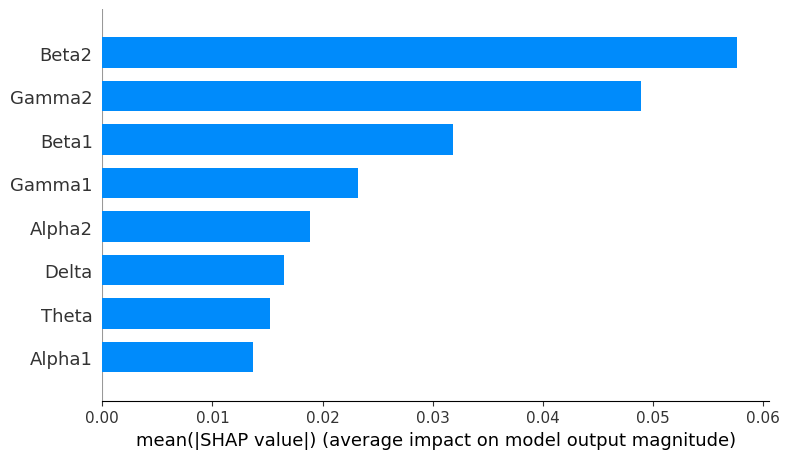

In [11]:
# Global Feature Importance - bar plot

shap.summary_plot(
    shap_values_confused,
    X_val,
    plot_type="bar",
    show=False
)

plt.tight_layout()
# plt.savefig("../reports/shap_feature_importance.png", dpi=300)
plt.show()


### Detailed features

In this plot, we can analyse whether a feature's high or low values influence the model towards confusion. We can see that lower Beta 2 power, higher Gamma 2 power and higher Beta 1 power are associated with increased confusion probability.




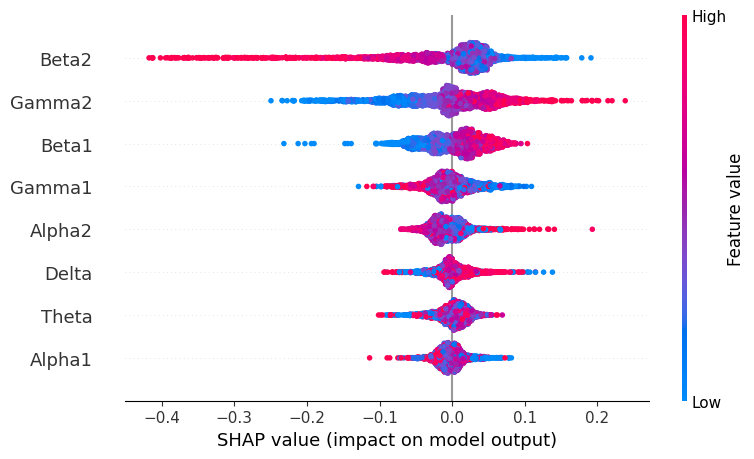

In [12]:
# Detailed Feature Effects: beeswarm plot

shap.summary_plot(
    shap_values_confused,
    X_val,
    show=False
)

plt.tight_layout()
# plt.savefig("../reports/shap_beeswarm.png", dpi=300)
plt.show()


SHAP analysis shows there's a dissociation within the beta band (reduced beta 2 power and elevated beta 1 power) and increase in gamma 2 power during confusion. Elevated low-beta (Beta1) power reflects compensatory cognitive effort under high task demand. In contrast, reduced high-beta (Beta2) power is consistent with impaired attentional control and reduced cognitive stability. Additionally, increased high-gamma (Gamma2) activity suggests cognitic overload without coordination. Together, this aligns with prior findings that confusion is associated with increased mental effort but reduced executive regulation.


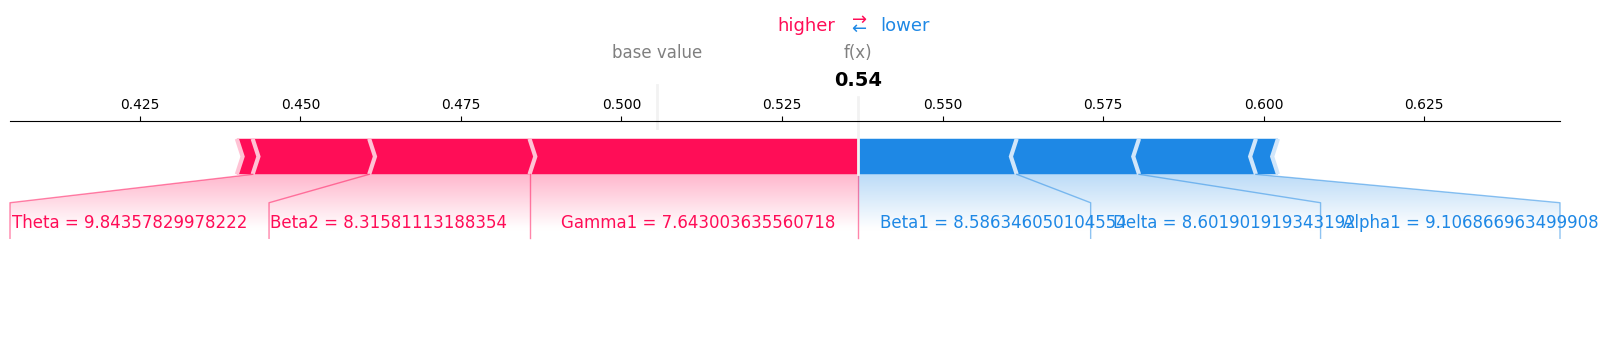

In [13]:
# Example single-sample explanation using SHAP values for the positive class


idx = 7  # example sample

shap.force_plot(
    shap_values_confused.base_values[idx],
    shap_values_confused.values[idx],
    X_val.iloc[idx],
    matplotlib=True
)


In [14]:
print(shap_values_confused.base_values[idx])
print(shap_values_confused.values[idx].sum())
print(shap_values_confused.base_values[idx]+ shap_values_confused.values[idx].sum())

0.505524931512773
0.03128755275160128
0.5368124842643742


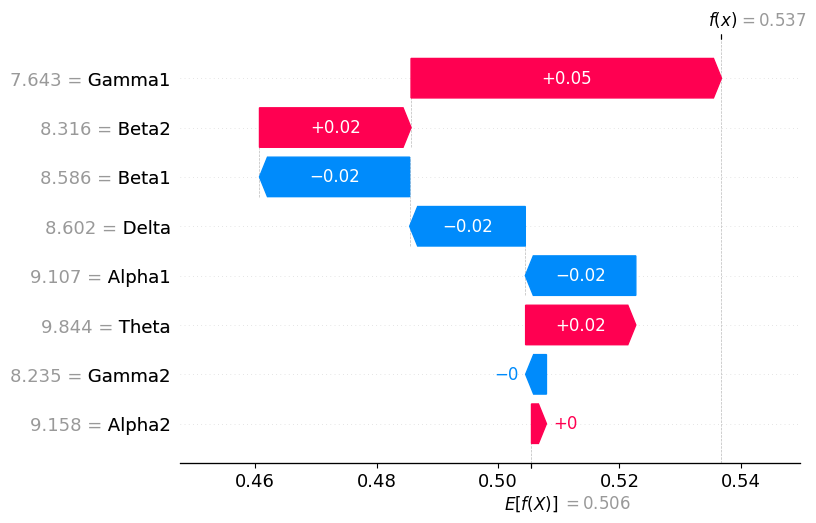

In [15]:
shap.plots.waterfall(shap_values_confused[idx])
